# Extended Data Figure 13

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

In [2]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


In [3]:
# load library

LIB = pd.read_csv(BASE + 'MBESv2_CORRECTED.csv')
LIB_FOCUSED = pd.read_csv(BASE + 'MBESv2_focused.csv')

ABE = LIB[LIB['Editor'] == 'ABE'].reset_index(drop=True)
ABE_FOCUSED = LIB_FOCUSED[LIB_FOCUSED['Editor'] == 'ABE'].reset_index(drop=True)

## 13a

Histograms showing the distribution of median LFC values for targeting guides (colored by tissue) and control guides (grey) in the original (OG, top row) and focused ABE screens with T0 baseline (bottom row), across three tissue contexts (Day 15 In Vitro, Spleen, and Bone Marrow). Dynamic range (DR), defined as the difference between the 95th and 5th percentiles of targeting guide LFC values, is annotated in each panel.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


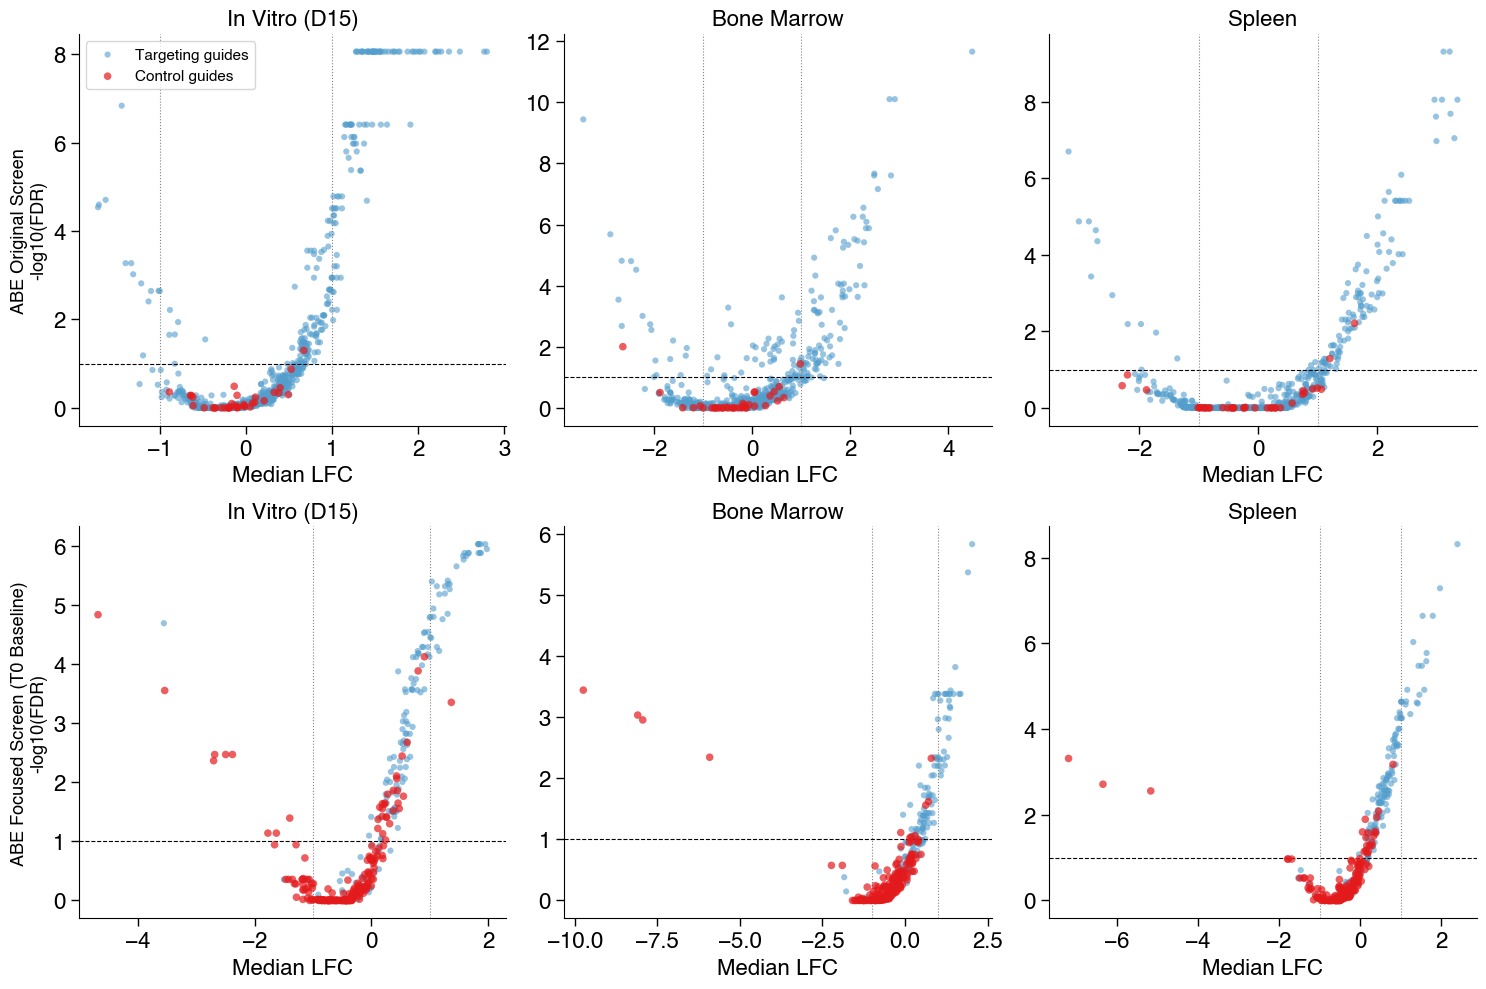

In [23]:
min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_og      = 10
min_sensor_focused = 100

conditions  = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro (D15)', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

screens = [
    (dfs['ABE_OG'],      min_sensor_og,      'ABE Original Screen'),
    (dfs['ABE_EPO_T0'],  min_sensor_focused,  'ABE Focused Screen (T0 Baseline)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (df, min_sensor, screen_label) in enumerate(screens):
    input_ok = df['Input_median'] >= 2

    for k, cond in enumerate(conditions):
        lfc_col   = f'LFC_median_{cond}'
        fdr_col   = f'FDR_{cond}_fishers'
        reads_col = f'sensor_reads_{cond}'
        edit_col  = f'target_base_edit_perc_{cond}'
        ax = axes[row, k]

        guide_ok = input_ok & (df[reads_col] >= min_sensor) & (df[edit_col] >= min_edit)

        targ = df[(df['classification'] == 'targeting guide') & guide_ok].copy()
        ntc  = df[df['classification'] == 'non-targeting control'].copy()
        stc  = df[df['classification'] == 'safe-targeting control'].copy()

        # targeting guides — solid blue
        if len(targ):
            neg_log_fdr = -np.log10(targ[fdr_col].clip(lower=1e-300))
            ax.scatter(targ[lfc_col], neg_log_fdr,
                       c=blues[3], s=20, alpha=0.6,
                       linewidths=0, edgecolors='none',
                       label='Targeting guides')

        # controls — red
        ctrl_plotted = False
        for ctrl_df in [ntc, stc]:
            if len(ctrl_df):
                yvals = -np.log10(ctrl_df[fdr_col].clip(lower=1e-300))
                ax.scatter(ctrl_df[lfc_col], yvals,
                           c='#e41a1c', s=30, alpha=0.7,
                           linewidths=0, edgecolors='none', zorder=3,
                           label='Control guides' if not ctrl_plotted else '_nolegend_')
                ctrl_plotted = True

        # threshold lines
        ax.axhline(-np.log10(FDR_cutoff), color='black', linestyle='--', linewidth=0.8)
        ax.axvline( LFC_cutoff, color='grey', linestyle=':', linewidth=0.8)
        ax.axvline(-LFC_cutoff, color='grey', linestyle=':', linewidth=0.8)

        ax.set_title(cond_labels[cond], fontsize=16)
        ax.set_xlabel('Median LFC', fontsize=16)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=16, direction='out', length=6, width=1)
        if k == 0:
            ax.set_ylabel(f'{screen_label}\n-log10(FDR)', fontsize=13)
        if row == 0 and k == 0:
            ax.legend(fontsize=11, loc='upper left')

fig.tight_layout()
plt.savefig('figures/ext-12/volcano_ABE_OG_and_focused_T0.pdf', bbox_inches='tight')
plt.show()


## 13b

Histograms showing the distribution of median LFC values for targeting guides (colored by tissue) and control guides (grey) in the ABE original (OG, top row) and focused ABE screen with T0 baseline (bottom row), across three tissue contexts (Day 15 In Vitro, Spleen, and Bone Marrow). Dynamic range (DR), defined as the difference between the 95th and 5th percentiles of targeting guide LFC values, is annotated in each panel.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


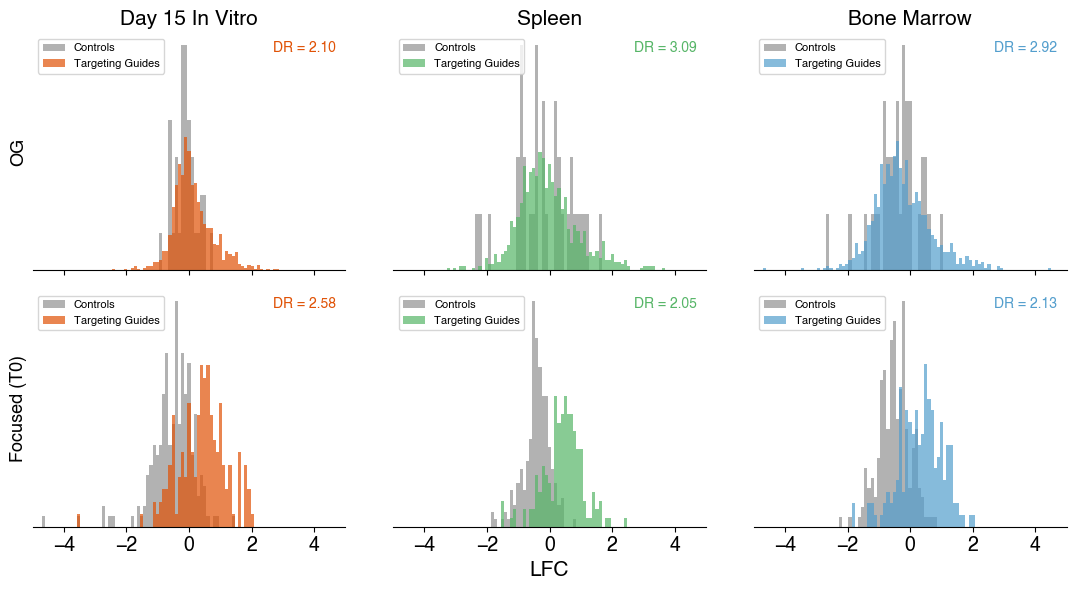

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=False)

conditions    = ['d15', 'spleen', 'bm']
name_dict     = {'d15': 'Day 15 In Vitro', 'spleen': 'Spleen', 'bm': 'Bone Marrow'}
tissue_colors = {'d15': yellows[4], 'spleen': greens[3], 'bm': blues[3]}

ABE_OG  = dfs['ABE_OG']
ABE_EPO = dfs['ABE_EPO_T0']

bins = np.linspace(-5, 5, 100)

for idx, cond in enumerate(conditions):
    lfc_col = f'LFC_median_{cond}'
    color   = tissue_colors[cond]

    for row, (df, screen_label) in enumerate([
        (ABE_OG,  'OG'),
        (ABE_EPO, 'Focused (T0)'),
    ]):
        ax = axes[row][idx]

        if lfc_col not in df.columns:
            ax.set_visible(False)
            continue

        targ = df[df['classification'] == 'targeting guide'][lfc_col].dropna()
        ctrl = df[df['classification'].isin(['non-targeting control', 'safe-targeting control'])][lfc_col].dropna()

        ax.hist(ctrl,  density=True, bins=bins, alpha=0.6, color='grey',  label='Controls')
        ax.hist(targ,  density=True, bins=bins, alpha=0.7, color=color,   label='Targeting Guides')

        dr = np.percentile(targ, 95) - np.percentile(targ, 5)
        ax.text(0.97, 0.97, f'DR = {dr:.2f}',
                transform=ax.transAxes, fontsize=10,
                ha='right', va='top', color=color)

        if row == 0:
            ax.set_title(name_dict[cond], fontsize=15)
        ax.set_xlim(-5, 5)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.set_yticks([])
        ax.tick_params(axis='x', which='major', labelsize=14)
        ax.legend(fontsize=8, loc='upper left', frameon=True)

axes[0][0].set_ylabel('OG', fontsize=13)
axes[1][0].set_ylabel('Focused (T0)', fontsize=13)
axes[1][1].set_xlabel('LFC', fontsize=15)

fig.tight_layout()
plt.savefig(BASE + 'figures/ext-12/12b.pdf', bbox_inches='tight', dpi=300)
plt.show()
